In [1]:
pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Note: you may need to restart the kernel to use updated packages.


In [127]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
X = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 

In [128]:
# necessary imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Combine features and target
df = pd.concat([X, y], axis=1)

# View first 5 rows
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [129]:
df.shape

(400, 25)

In [130]:
# rename column names to make it more user-friendly

df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [131]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [133]:
# converting necessary columns to numerical type

columns_to_convert = [
    'packed_cell_volume',
    'white_blood_cell_count',
    'red_blood_cell_count'
]

for column in columns_to_convert:
    df[column] = pd.to_numeric(df[column], errors='coerce')

In [134]:
# Recheck data types after conversion
df[columns_to_convert].dtypes

packed_cell_volume        float64
white_blood_cell_count    float64
red_blood_cell_count      float64
dtype: object

In [135]:
# Separate Numeric and Categorical Columns

numeric_columns = [col for col in df.columns if df[col].dtype != 'object']
categorical_columns = [col for col in df.columns if df[col].dtype == 'object']

print(len(numeric_columns), "numerical columns")
print(len(categorical_columns), "categorical columns")

14 numerical columns
11 categorical columns


In [136]:
df.isnull().sum()

age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
haemoglobin                 52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [137]:
df.isna().sum().sort_values(ascending = False)

red_blood_cells            152
red_blood_cell_count       131
white_blood_cell_count     106
potassium                   88
sodium                      87
packed_cell_volume          71
pus_cell                    65
haemoglobin                 52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
bacteria                     4
pus_cell_clumps              4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [138]:
# Looking at unique values in categorical columns

for col in categorical_columns:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' '\tno' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

appetite has ['good' 'poor' nan] values

peda_edema has ['no' 'yes' nan] values

aanemia has ['no' 'yes' nan] values

class has ['ckd' 'ckd\t' 'notckd'] values



In [139]:
# =========================
# Clean incorrect categorical values
# =========================

df['diabetes_mellitus'] = df['diabetes_mellitus'].replace({
    '\tno': 'no',
    '\tyes': 'yes',
    ' yes': 'yes'
})

df['coronary_artery_disease'] = df['coronary_artery_disease'].replace({
    '\tno': 'no'
})

df['class'] = df['class'].replace({
    'ckd\t': 'ckd',
    'notckd': 'not ckd'
})

df['class'] = df['class'].map({
    'ckd': 0,
    'not ckd': 1
})

df['class'] = pd.to_numeric(df['class'], errors='coerce')

In [140]:
# Check cleaned values

check_cols = ['diabetes_mellitus', 'coronary_artery_disease', 'class']

for col in check_cols:
    print(f"{col} has {df[col].unique()} values\n")

diabetes_mellitus has ['yes' 'no' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

class has [0 1] values



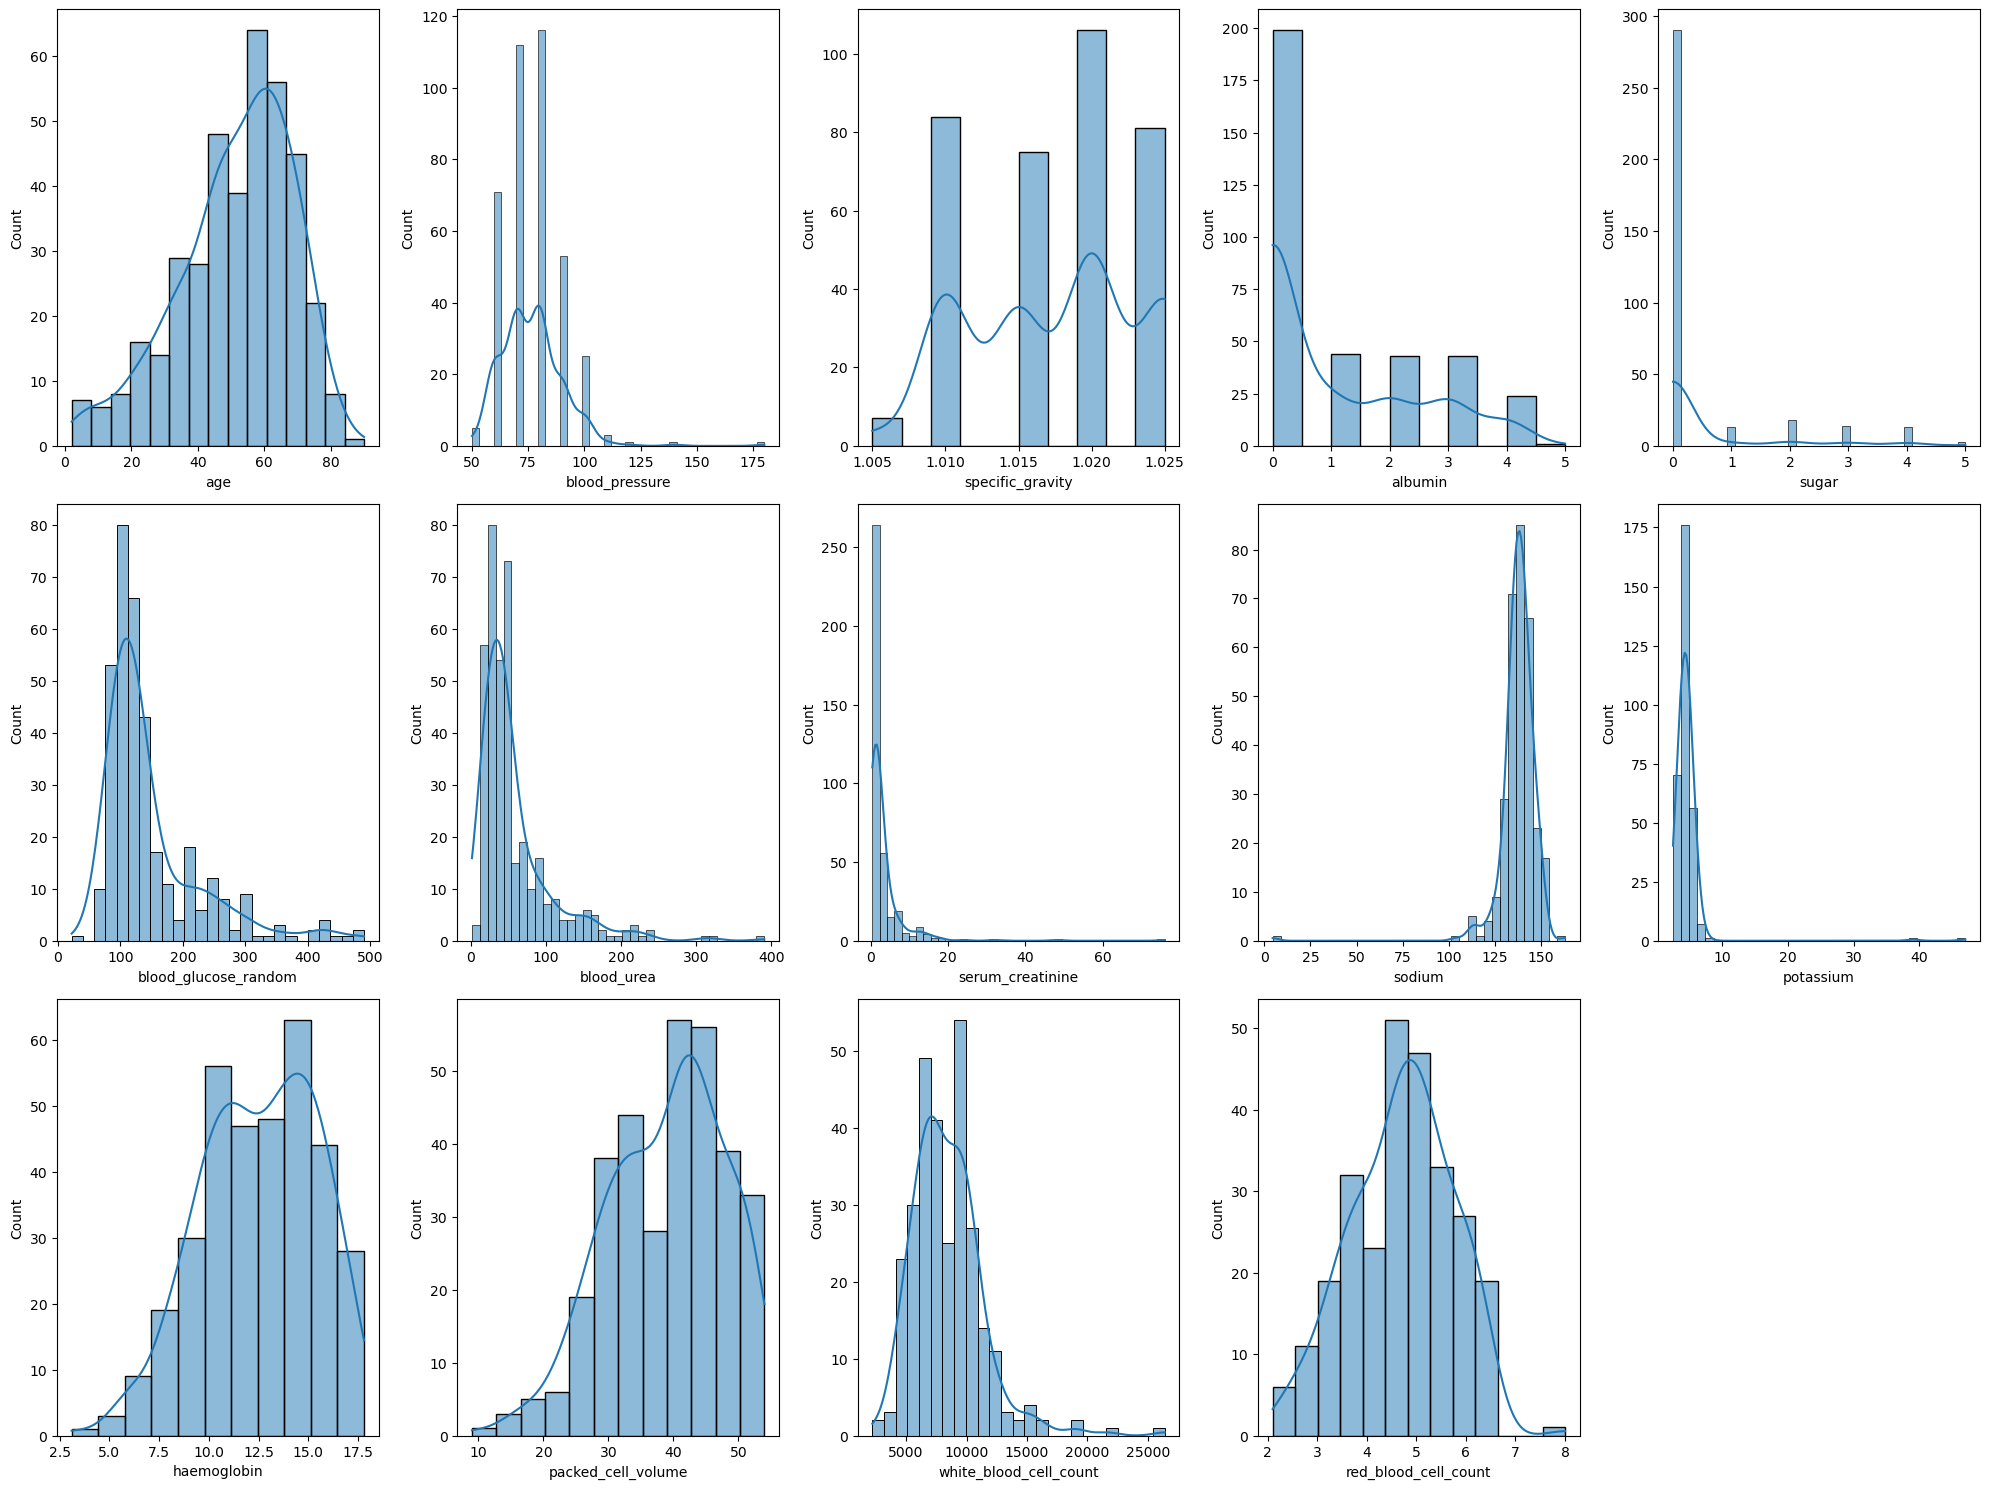

In [141]:
# Checking numerical feature distribution

plt.figure(figsize=(20, 15))
plot_number = 1

for column in numeric_columns:
    if plot_number <= 15:
        plt.subplot(3, 5, plot_number)
        sns.histplot(df[column], kde=True)
        plt.xlabel(column)
        
    plot_number += 1

plt.tight_layout()
plt.show()

C:\Users\drhud\AppData\Local\Temp\ipykernel_16660\1518032609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\drhud\AppData\Local\Temp\ipykernel_16660\1518032609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\drhud\AppData\Local\Temp\ipykernel_16660\1518032609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\drhud\AppData\Local\Temp\ipykernel_16660\1518032609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

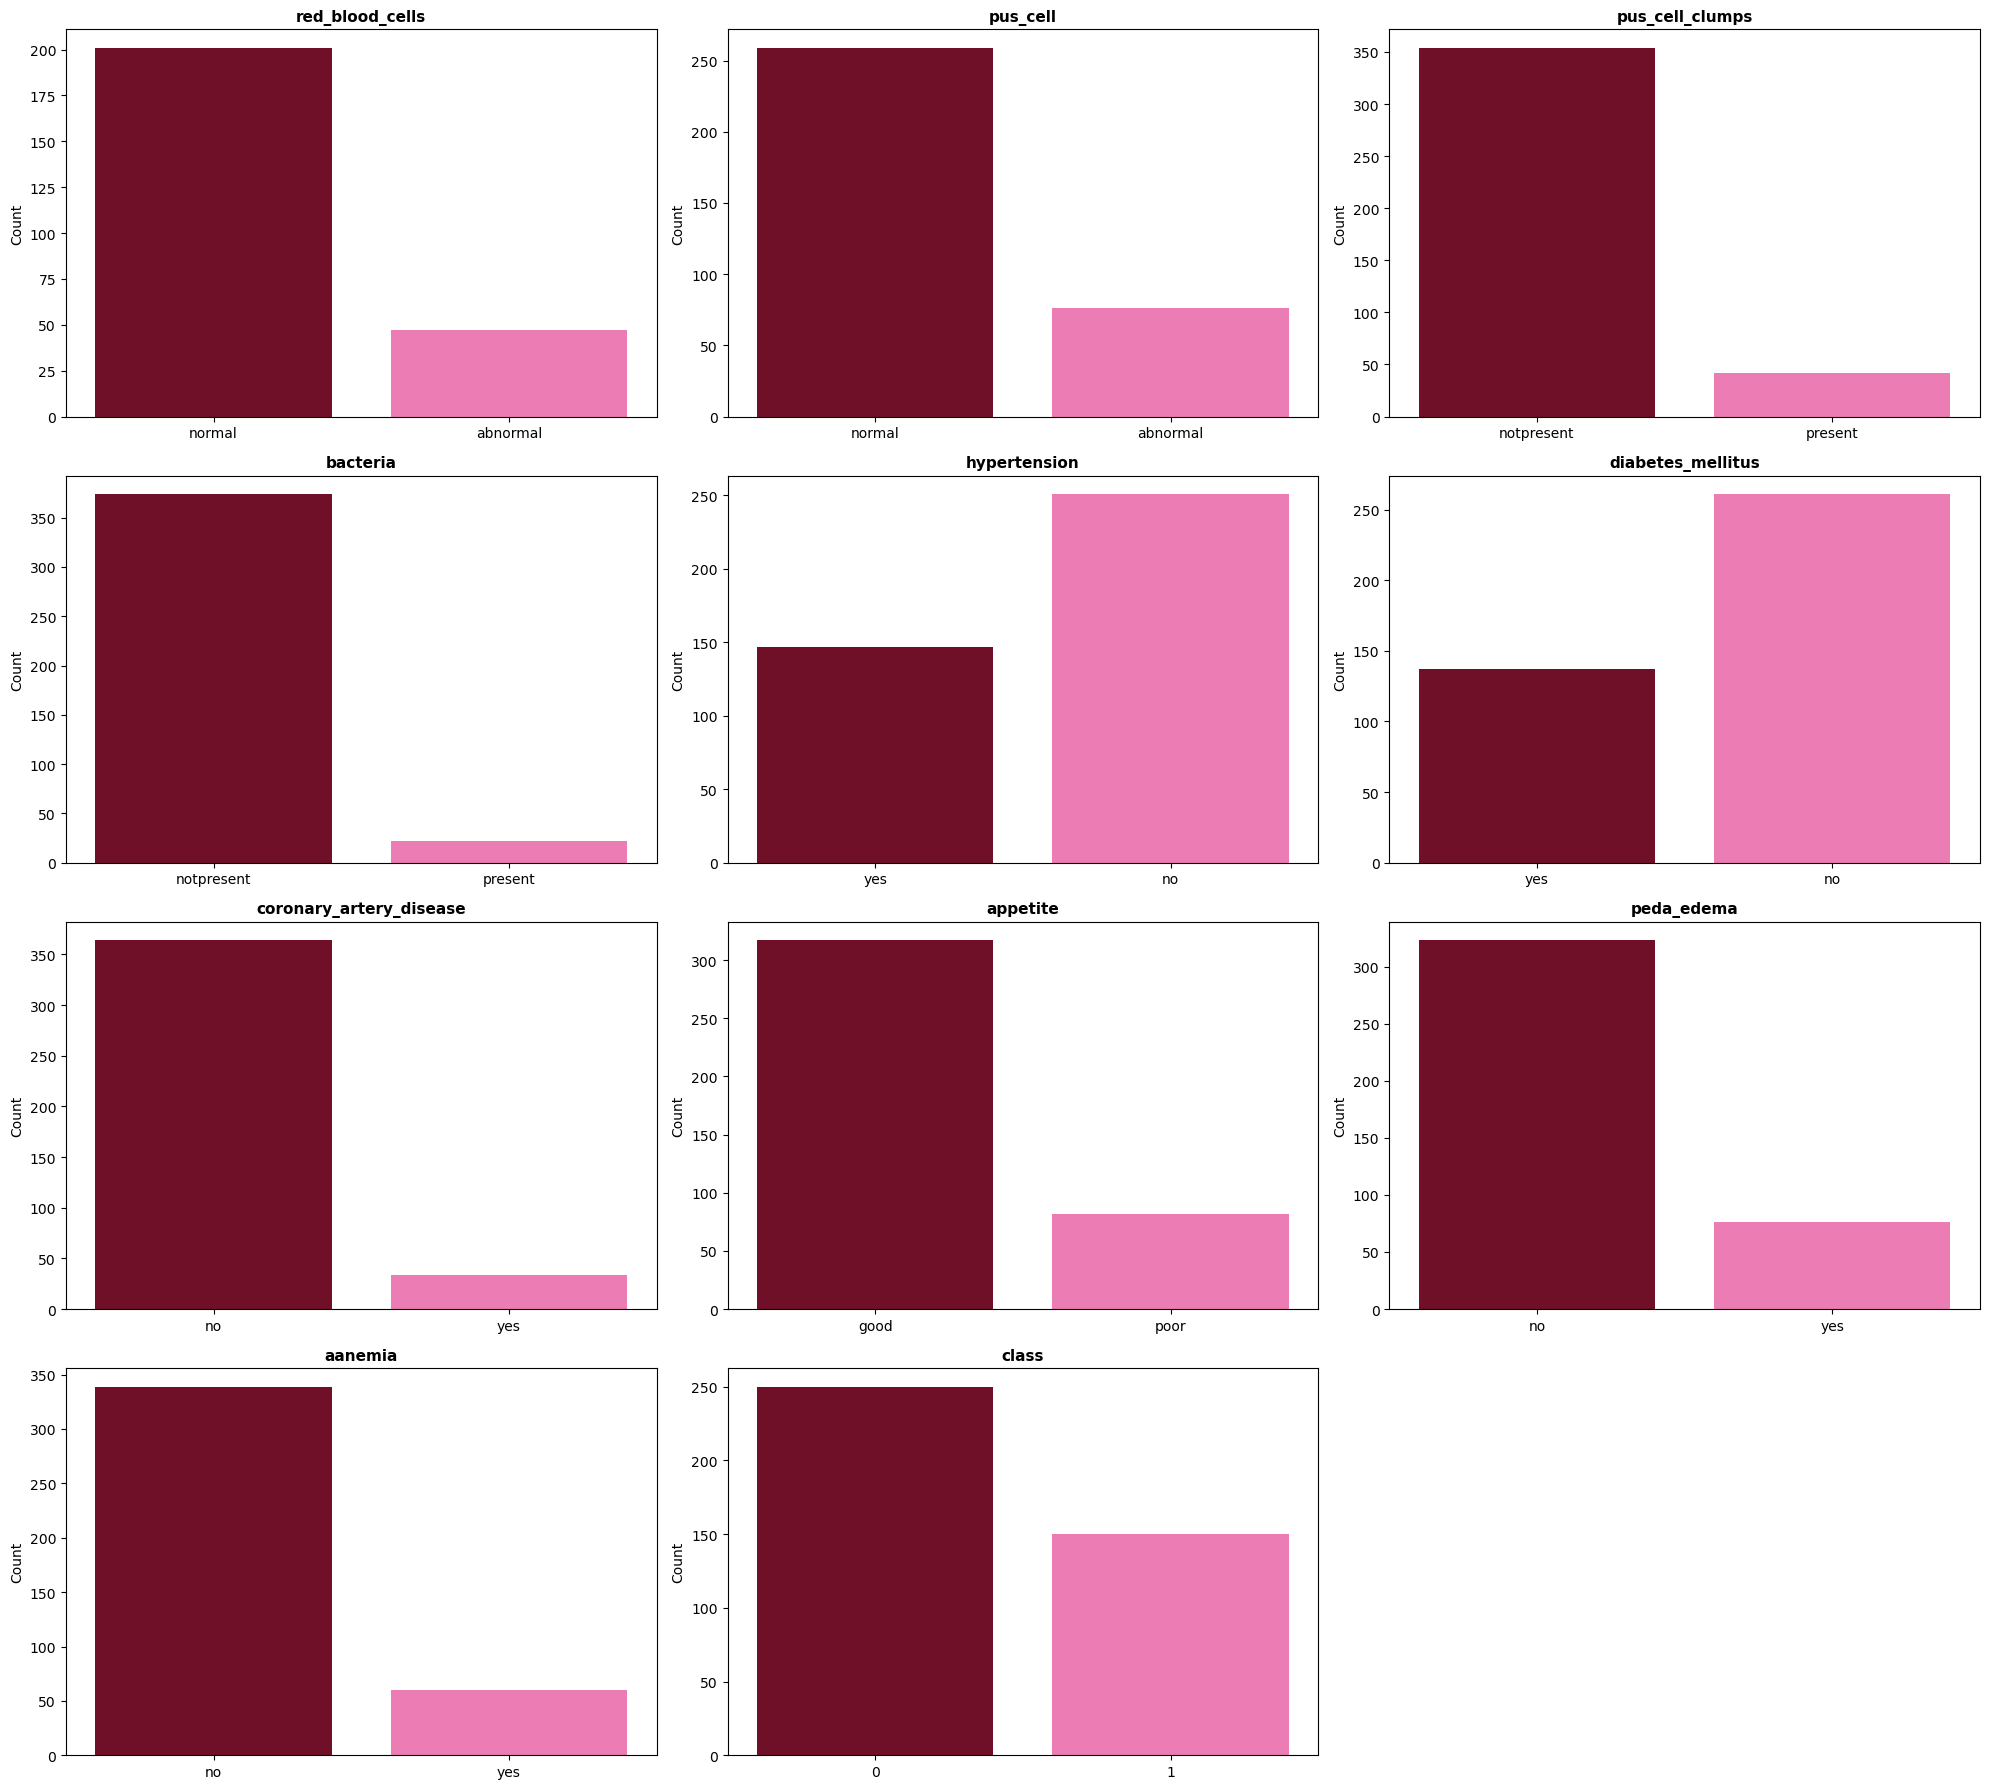

In [142]:
# Distribution of categorical variables

palette = ['#800020', '#FF69B4']

plt.figure(figsize=(20,18))
plot_number = 1

for column in categorical_columns:

    plt.subplot(4,3,plot_number)

    sns.countplot(
        x=data[column],
        palette=palette
    )

    plt.title(column, fontsize=11, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Count')

    plot_number += 1

plt.tight_layout()
plt.show()

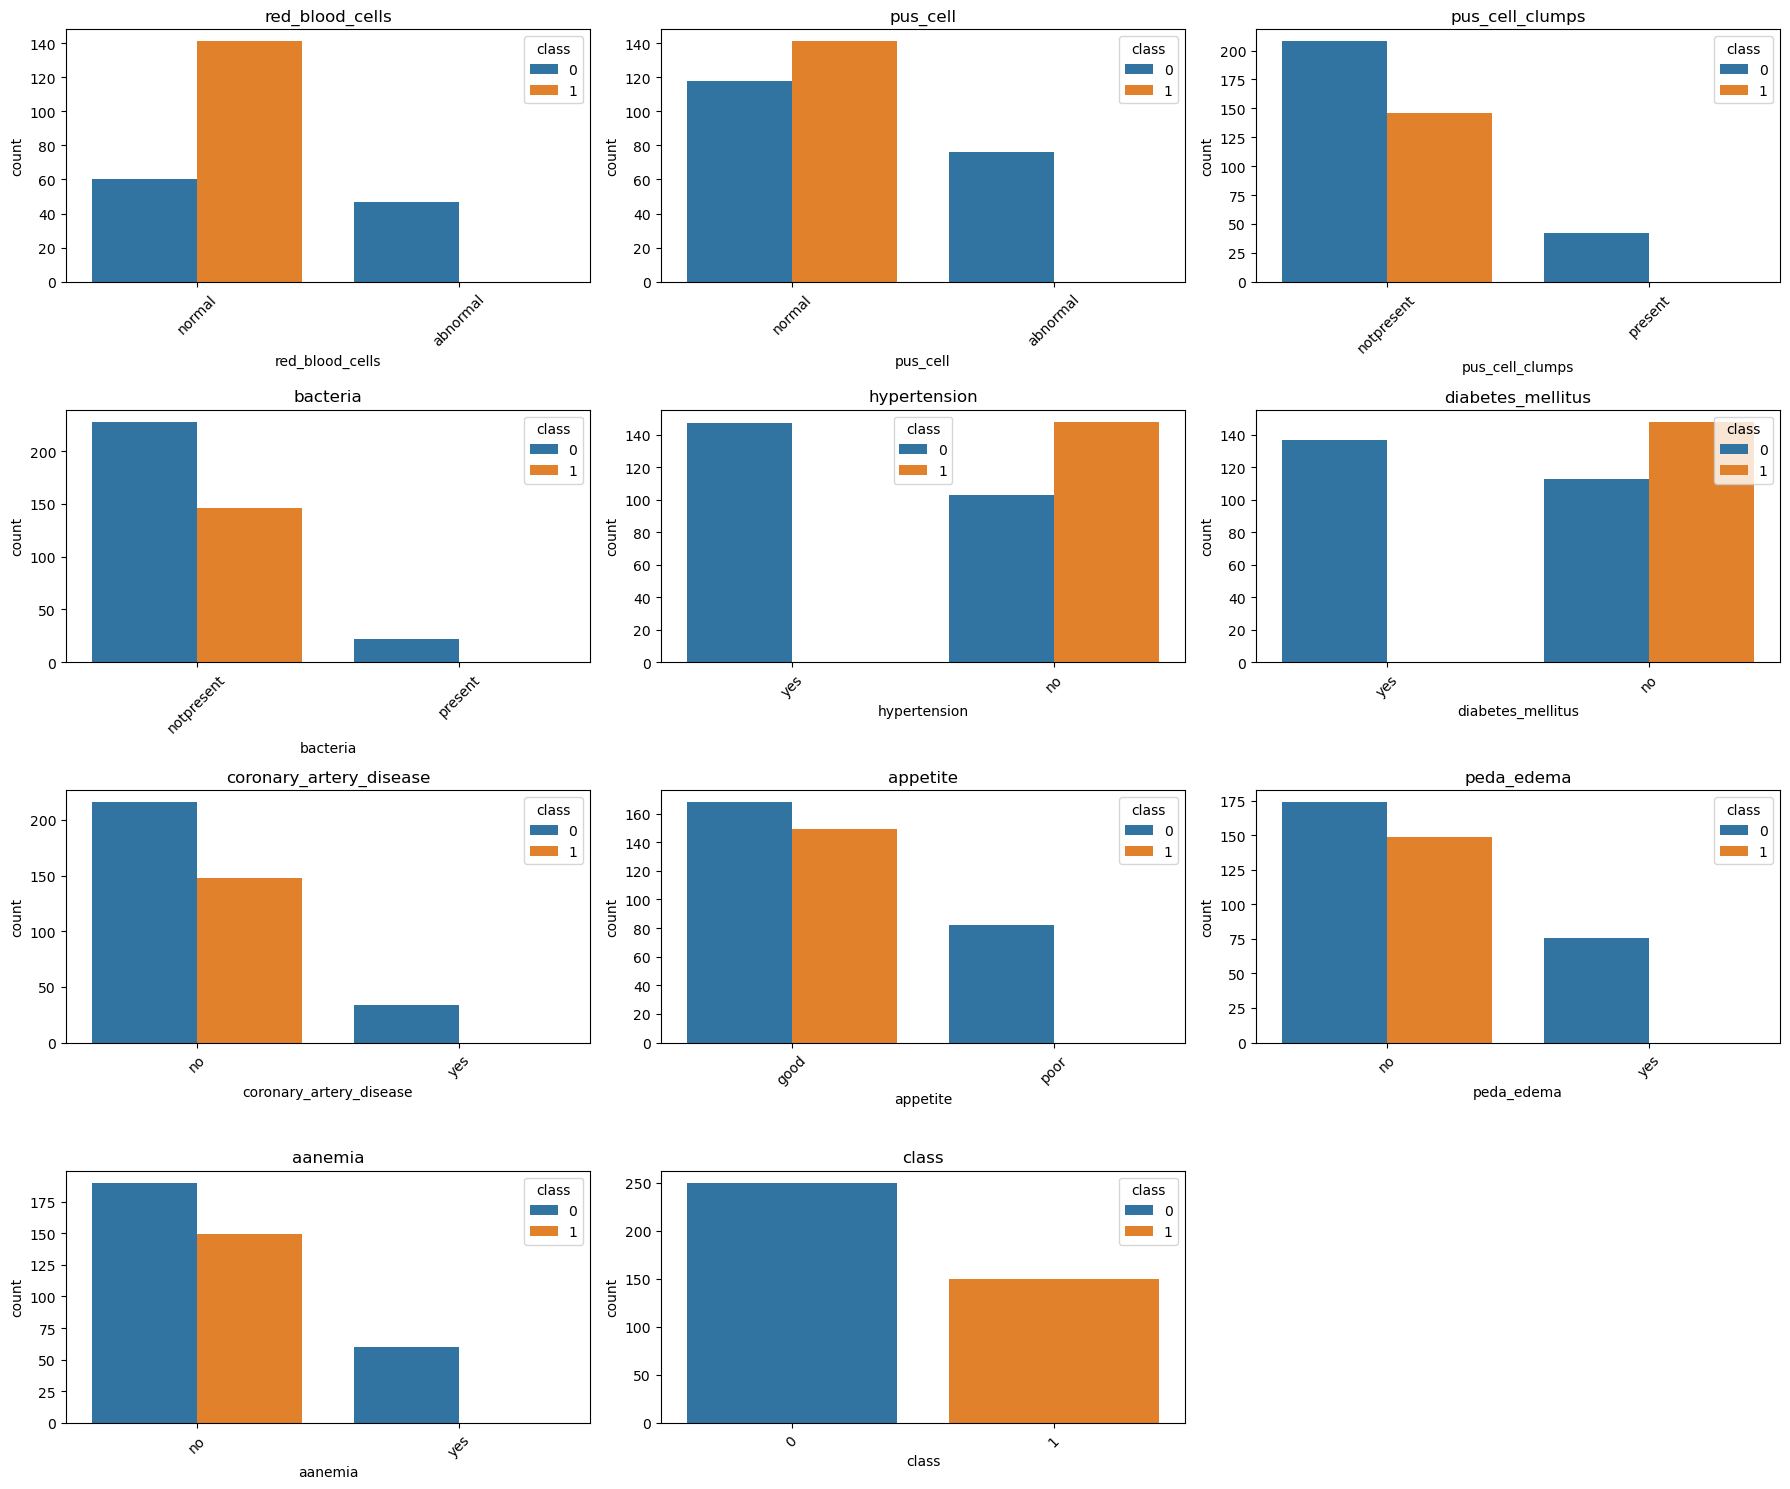

In [143]:
# Categorical Variables vs Target

plt.figure(figsize=(18, 15))

plot_number = 1

for column in categorical_columns:
    
    plt.subplot(4, 3, plot_number)
    
    sns.countplot(
        x=column,
        hue='class',
        data=df
    )
    
    plt.xticks(rotation=45)
    plt.title(column)
    
    plot_number += 1

plt.tight_layout()
plt.show()

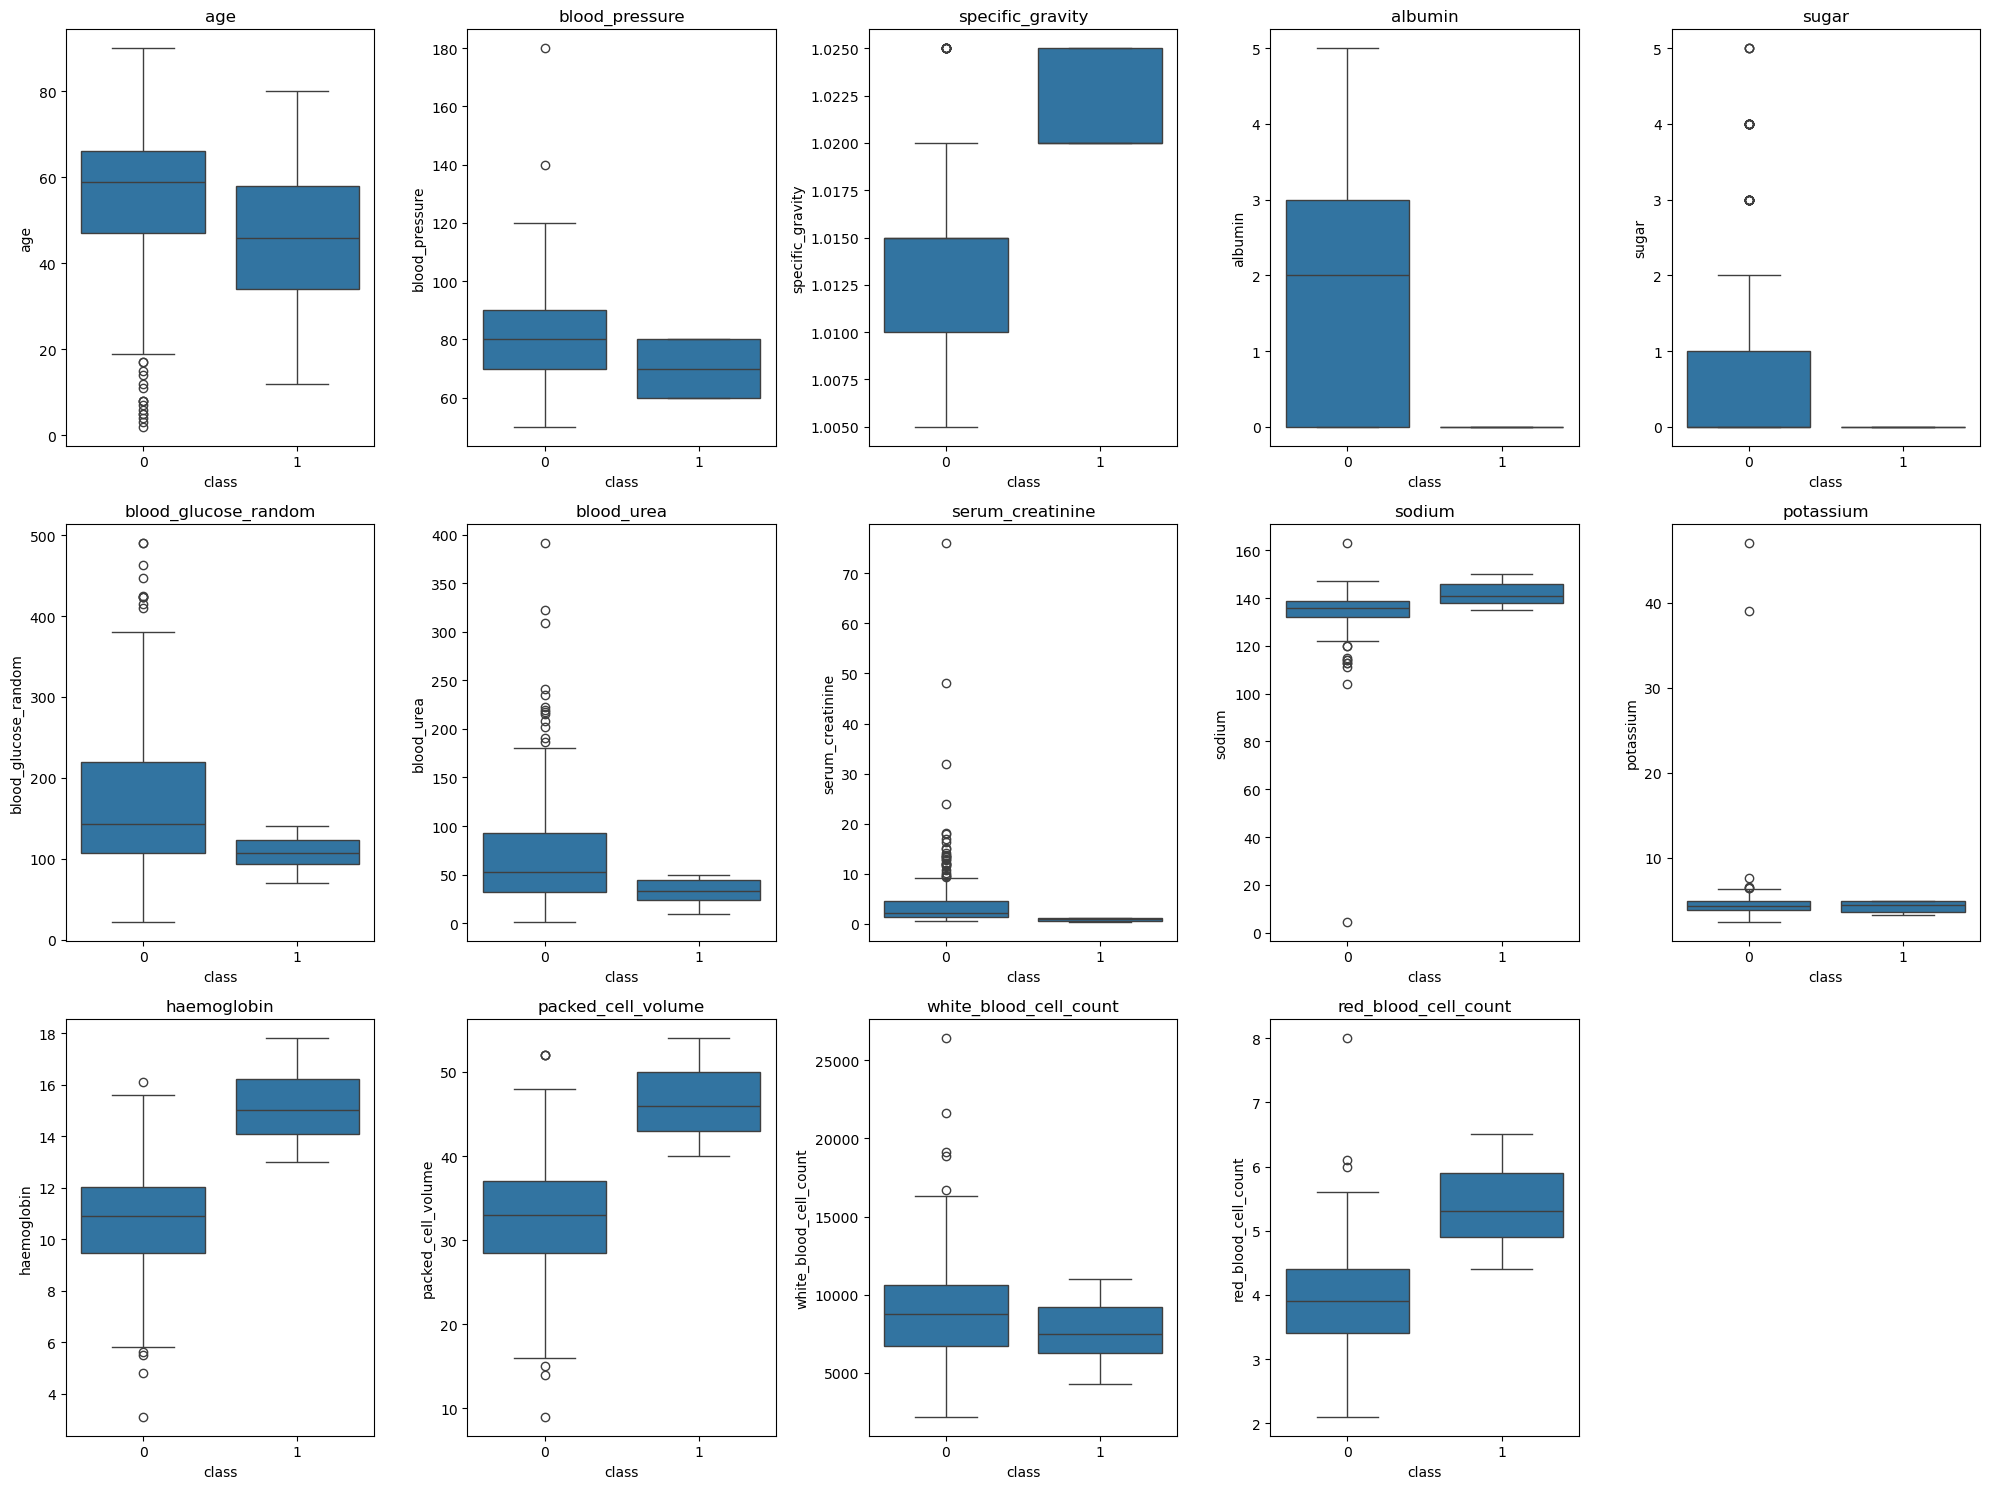

In [145]:
# Numerical Variables vs Target

plt.figure(figsize=(20, 15))

plot_number = 1

for column in numeric_columns:

    plt.subplot(3, 5, plot_number)

    sns.boxplot(
        x='class',
        y=column,
        data=df
    )

    plt.title(column)

    plot_number += 1

plt.tight_layout()
plt.show()

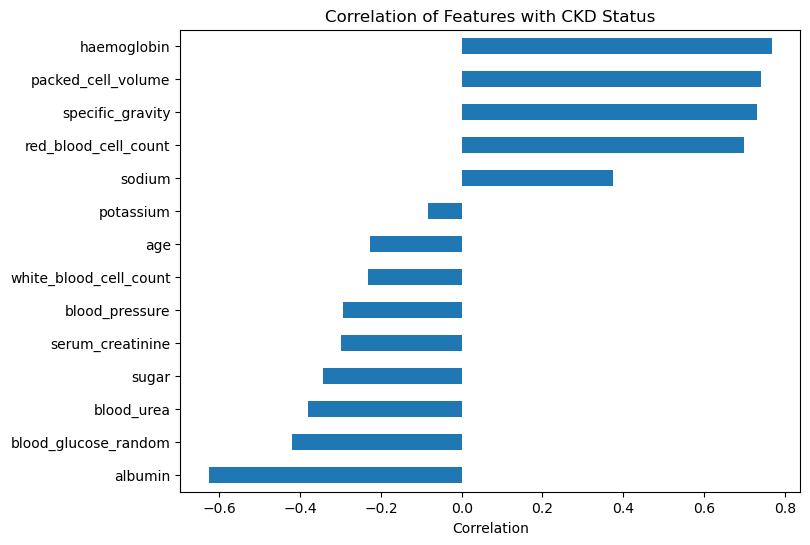

In [146]:
# Correlation with Target

corr_target = data.corr(numeric_only=True)['class'].sort_values()

plt.figure(figsize=(8,6))

corr_target.drop('class').plot(kind='barh')

plt.title('Correlation of Features with CKD Status')
plt.xlabel('Correlation')

plt.show()

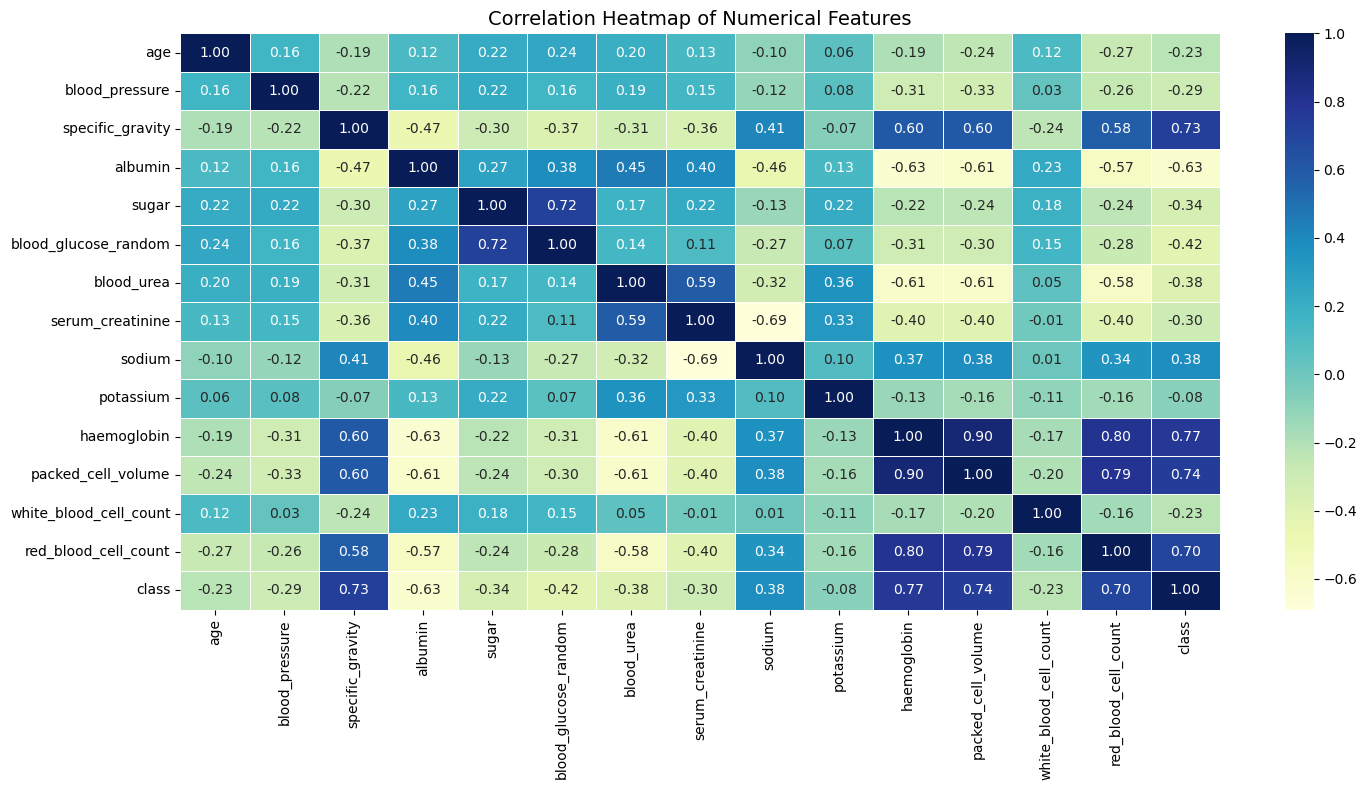

In [147]:
# Correlation Heatmap

plt.figure(figsize=(15,8))

corr_matrix = data.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()